In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data_base = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/PROCESS_GE2000_BASE.xlsx', sheet_name=None)

data_harvested_area = data_base['harvested area']
data_planted_area = data_base['planted area']
data_production = data_base['production']
data_census_irrigated_harvested = data_base['census irrigated harvested']
data_census_overall_harvested = data_base['census overall harvested']
data_water_applied = data_base['water applied']


In [4]:
data_applications = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/PROCESS_GE2000_APPLICATIONS.xlsx', sheet_name=None)
print(data_applications)

data_HERBICIDE = data_applications['CHEMICAL, HERBICIDE (TOTAL)']
data_INSECTICIDE = data_applications['CHEMICAL, INSECTICIDE (TOTAL)']
data_OTHERCHEMICAL = data_applications['CHEMICAL, OTHER (TOTAL)']
data_NITROGEN = data_applications['FERTILIZER (NITROGEN)']
data_PHOSPHATE = data_applications['FERTILIZER (PHOSPHATE)']
data_POTASH = data_applications['FERTILIZER (POTASH)']
data_SULFUR = data_applications['FERTILIZER (SULFUR)']

print(data_production, data_HERBICIDE,data_INSECTICIDE )

{'CHEMICAL, FUNGICIDE (TOTAL)':        state_name     2007    2017     2019    2021
0         ALABAMA      NaN     NaN   5000.0     NaN
1        ARKANSAS  16000.0  7000.0  15000.0     NaN
2      CALIFORNIA   1000.0     NaN      NaN     NaN
3         GEORGIA      NaN  9000.0  31000.0     NaN
4     MISSISSIPPI   3000.0     NaN      NaN     NaN
5        MISSOURI      NaN  9000.0      NaN  5000.0
6  NORTH CAROLINA  15000.0     NaN      NaN     NaN
7  SOUTH CAROLINA  13000.0     NaN      NaN     NaN, 'CHEMICAL, HERBICIDE (TOTAL)':         state_name        2007        2015        2017      2019        2021
0          ALABAMA    941000.0    997000.0   1422000.0   1900000   1177000.0
1          ARIZONA         NaN    353000.0         NaN    329000         NaN
2         ARKANSAS   2399000.0    752000.0   1681000.0   2210000   1239000.0
3       CALIFORNIA    565000.0    295000.0         NaN    609000         NaN
4          GEORGIA   3163000.0   4370000.0   4409000.0   4445000   3427000.0
5     

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8

['/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf']


In [6]:
data_energy = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/processed_data and results/Processed_Energy.xlsx',
                            usecols=[0,1,2,4,5], nrows=24,
                            names=['year','diesel','diesel tax', 'elec', 'total price'])

data_energy = data_energy.set_index('year')

data_total_price = data_energy['total price']
print(data_total_price)


data_planted_area_sum = data_planted_area.sum(axis=0)
print(data_planted_area_sum)

data_production_sum = data_production.sum(axis=0)
print(data_production_sum)

data_total_price_per_bale = data_total_price*data_planted_area_sum/data_production_sum
print(data_total_price_per_bale)
#convert per bale to per 1000kg, 1000kg = 4.593*480lb
data_energy['price per 1000kg'] = data_total_price_per_bale*4.593

# convert gallon to liter: 1 gallon = 3.785 liter
# exclude the federal tax (0.244) and state tax
data_energy['diesel liter'] = (data_energy['diesel']-data_energy['diesel tax']-0.244)/3.785

year
2023    48.10
2022    55.17
2021    38.50
2020    29.41
2019    34.97
2018    44.62
2017    43.27
2016    38.18
2015    43.49
2014    64.01
2013    63.97
2012    64.50
2011    62.95
2010    51.74
2009    40.77
2008    61.28
2007    48.86
2006    39.00
2005    37.99
2004    28.63
2003    24.39
2002    31.37
2001    36.49
2000    36.97
Name: total price, dtype: float64
Category    ALABAMAARIZONAARKANSASCALIFORNIAFLORIDAGEORGIA...
2023                                                 10232500
2022                                                 13749000
2021                                                 11206500
2020                                                 12086000
2019                                                 13722700
2018                                                 14081300
2017                                                 12717500
2016                                                 10073500
2015                                                  8580500
2014 

      diesel  diesel tax    elec  total price price per 1000kg  diesel liter
year                                                                        
2023   4.214      0.3347  0.0804        48.10       181.807758      0.960449
2022   4.989      0.3218  0.0832        55.17       240.803082      1.168613
2021   3.287      0.3089  0.0718        38.50       113.088569      0.722351
2020   2.551      0.2809  0.0667        29.41       111.763029      0.535297
2019   3.056      0.2786  0.0681        34.97       110.689355      0.669326
2018   3.178      0.2654  0.0692        44.62       157.119662      0.705046
2017   2.650      0.2760  0.0688        43.27       120.801273      0.562748
2016   2.304      0.2506  0.0676        38.18       102.883326      0.478045
2015   2.707      0.2504  0.0691        43.49       132.988143      0.584571
2014   3.825      0.2256  0.0710        64.01       200.841117      0.886499
2013   3.922      0.2190  0.0689        63.97       236.863979      0.913871

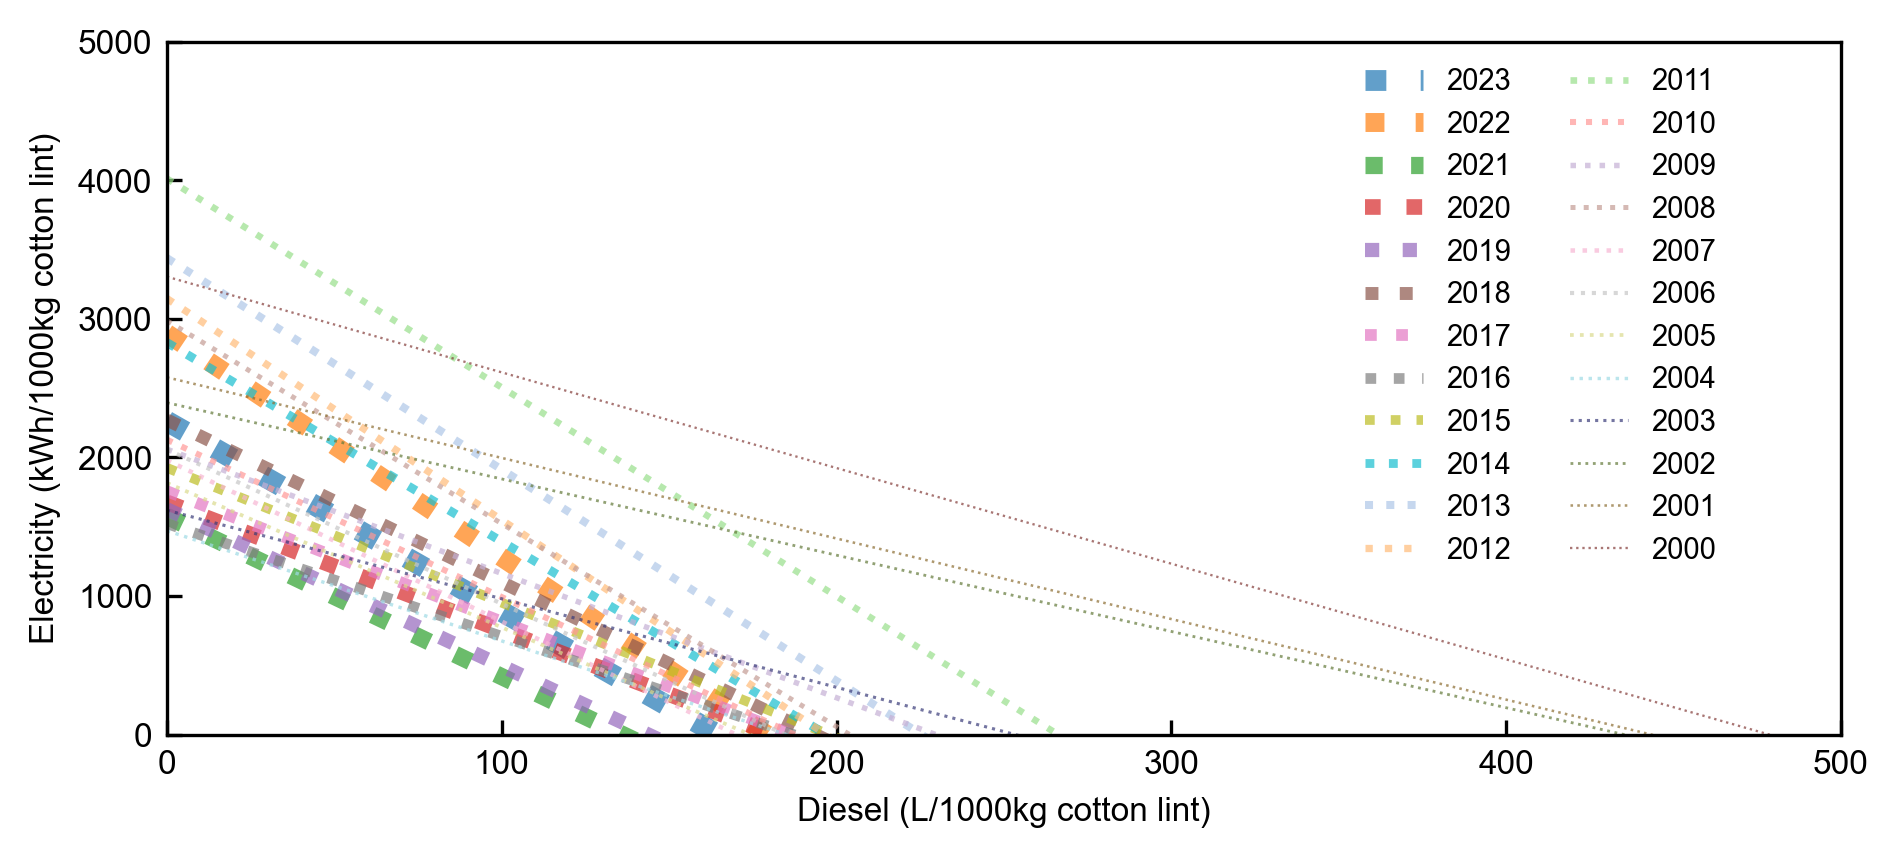

In [24]:
print(data_energy)

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



# Define the range of x
x = np.linspace(0, 600, 400)
# y = np.linspace(0, 200, 400)

plt.figure(figsize=(7.2, 3))

# linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 5)), (0, (3, 5, 1, 5))]
linestyles = [':']
# Iterate through the DataFrame to plot each equation
# colors = plt.cm.get_cmap('viridis')(np.linspace(0, 1, len(data_energy.index)))
# colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(data_energy.index)))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
          '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78',
          '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d3', '#c7c7c7',
          '#dbdb8d', '#9edae5', '#393b79', '#637939', '#8c6d31', '#843c39']
i = 5
coefficients = []
k = 0
for index, row in data_energy.iterrows():
    a, b, c = 1.15*row['diesel liter'], row['elec'], row['price per 1000kg']
    coefficients.append((a, b, c))
    y = (c - a * x) / b

    # Cycle through linestyles
    linestyle = linestyles[k % len(linestyles)]

    plt.plot(x, y, label=index, linewidth=i, color=colors[k],
             linestyle=linestyle, alpha=0.7)
    i =i/1.1
    k += 1
# Additional plot formatting
plt.xlim(0, 500)
plt.ylim(0, 5000)  # Adjust as needed based on the range of your data
plt.xlabel('Diesel (L/1000kg cotton lint)')
plt.ylabel('Electricity (kWh/1000kg cotton lint)')
plt.legend(bbox_to_anchor=(0.7, 1), loc='upper left', fontsize=7, frameon=False, ncol=2)

# plt.grid(True)
# plt.title('Visualizing Multiple Linear Equations')
# plt.set_rasterized(True)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig2_energy1.eps',bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_linearprogram.tiff',dpi=300, bbox_inches='tight')
plt.show()


[(np.float64(262.109406630352), np.float64(-1339.50757927523)), (np.float64(316.5211349861402), np.float64(-2087.003256455927)), (np.float64(129.906229075385), np.float64(476.6689458613308)), (np.float64(261.15897273957535), np.float64(-1326.450739394017)), (np.float64(-4.564577111553444), np.float64(2323.9976260767794)), (np.float64(116.69692137387982), np.float64(658.135344812329)), (np.float64(131.9004655679512), np.float64(449.2725884487907)), (np.float64(83.98939266648047), np.float64(1107.4637719517646)), (np.float64(913.7442292156207), np.float64(-10291.515311833908)), (np.float64(776.3061396536649), np.float64(-8403.422782301042)), (np.float64(394.9612423023941), np.float64(-3164.595218855929)), (np.float64(1315.9135415332157), np.float64(-15816.42384784729)), (np.float64(55.875878268558544), np.float64(1493.6806982988285)), (np.float64(42.377293395545145), np.float64(1679.121119795031)), (np.float64(801.4393128098365), np.float64(-8748.696473392562)), (np.float64(134.349133138

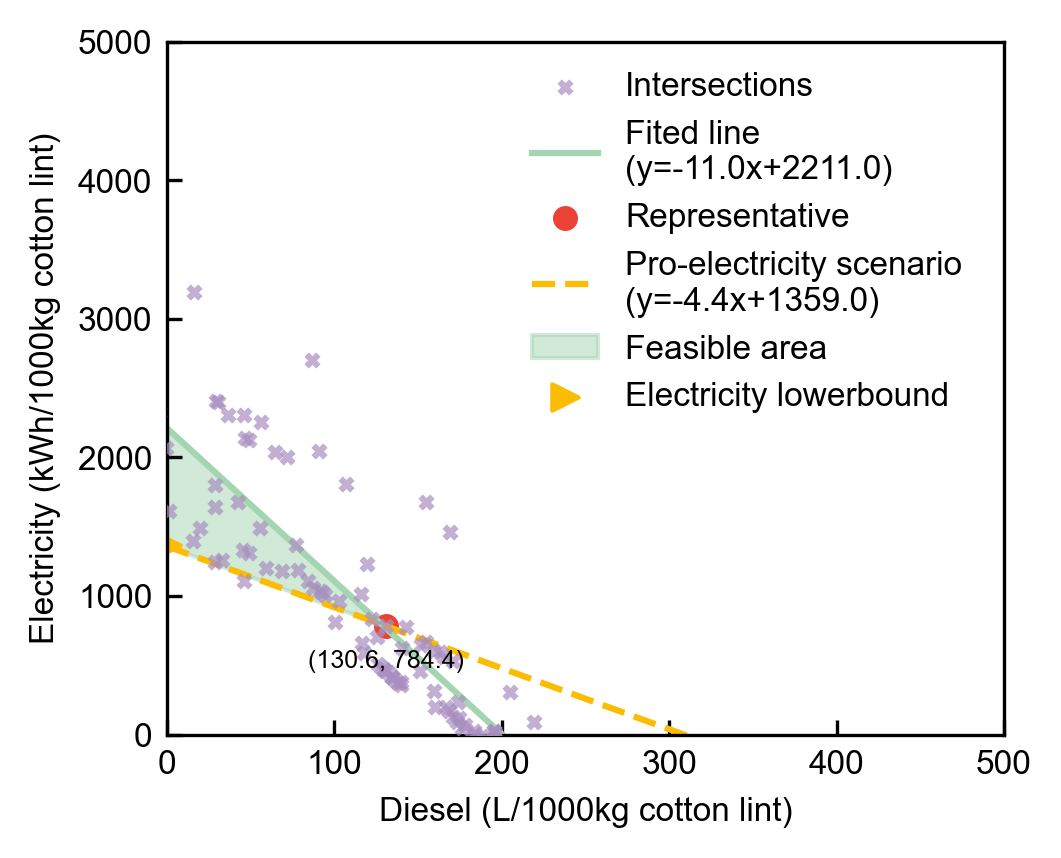

In [8]:
def find_intersection(coef1, coef2):
    a1, b1, c1 = coef1
    a2, b2, c2 = coef2

    denominator = a1 * b2 - a2 * b1

    if denominator == 0:
        return None  # Lines are parallel, no intersection

    x = (c1 * b2 - c2 * b1) / denominator
    y = (c1 - a1 * x) / b1  # You could also use coef2 here

    return (x, y)

from itertools import combinations
import matplotlib

# Given coefficients (a, b, c) for each line

# Calculate intersections
intersections = []
for coef1, coef2 in combinations(coefficients, 2):
    intersection = find_intersection(coef1, coef2)
    if intersection is not None:
        intersections.append(intersection)

print(intersections)


x_intersections, y_intersections = zip(*intersections)




matplotlib.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] =8

# Plotting the intersections
plt.figure(figsize=(3.6, 3))
plt.scatter(x_intersections, y_intersections, color='#A88EC0', marker='x', s=8, zorder=3, alpha=0.7, label='Intersections')

plt.xlim(0, 500)
plt.ylim(0, 5000)



def filter_points_within_limits(intersections):
    # Filter points based on the specified x and y limits
    filtered_points = [(x, y) for x, y in intersections if 0 <= x <= 500 and 0 <= y <= 5000]
    return filtered_points

# Apply the filter function to the intersection points
filtered_intersections = filter_points_within_limits(intersections)


from scipy.spatial.distance import pdist, squareform

# Let's assume 'intersections' is the list of your intersection points
filtered_intersections = np.array(filtered_intersections)  # Convert list of tuples to a numpy array for easier handling

# Calculate pairwise distances between points
dist_matrix = squareform(pdist(filtered_intersections))

# Calculate the average distance from each point to all others
average_distances = dist_matrix.sum(axis=1) / (len(filtered_intersections) - 1)

# Find the index of the point with the smallest average distance
closest_index = np.argmin(average_distances)

# The intersection point closest to all others
closest_point = filtered_intersections[closest_index]

print(closest_point)

## find a line to fit the intersections

x_filtered_intersections, y_filtered_intersections = zip(*filtered_intersections)
# print(x_filtered_intersections, y_filtered_intersections)

slope, intercept = np.polyfit(np.array(x_filtered_intersections), np.array(y_filtered_intersections), 1)
print(np.array(x_filtered_intersections), np.array(y_filtered_intersections))
# Use the slope and intercept found to calculate the line's y values
fit_line = slope * np.array(x_filtered_intersections) + intercept

plt.plot(np.arange(0,400,1), slope * np.arange(0,400,1) + intercept, linestyle='-',label='Fited line \n(y=-11.0x+2211.0)', color='#A4D5B1')
plt.scatter(closest_point[0],closest_point[1] ,color='#EA4335', s=25, label='Representative')
# Fill the area below the line
# plt.fill_between(np.arange(0,400,1), slope * np.arange(0,400,1) + intercept, color='#EA4335', alpha=0.15, label='Feasible area')


plt.plot(np.arange(0,400,1), -4.4 * np.arange(0,400,1) + 1359.0, linestyle='--',label='Pro-electricity scenario \n(y=-4.4x+1359.0)', color='#FBBC04')

plt.fill_between(np.arange(0, 130, 1), -4.4 * np.arange(0,130,1) + 1359.0, slope * np.arange(0,130,1) + intercept, color='#A4D5B1', alpha=0.5, label='Feasible area')

# plt.scatter(0,2211.0 , color='#EA4335', marker='v', s=40, label='Electricity upperbound')
plt.scatter(0,1370.5 , color='#FBBC04', marker='>', s=40, label='Electricity lowerbound')

print(slope, intercept)


# plt.scatter(closest_point[0],closest_point[1] , color='#EA4335', s=25, label='Representative')
# plt.text(closest_point[0],closest_point[1])
# Annotating the red dot
plt.annotate(f'({closest_point[0]:.1f}, {closest_point[1]:.1f})', (closest_point[0],closest_point[1]), textcoords="offset points", xytext=(0,-10), ha='center', fontsize=6)


plt.xlabel('Diesel (L/1000kg cotton lint)')
plt.ylabel('Electricity (kWh/1000kg cotton lint)')
plt.legend(bbox_to_anchor=(0.4, 1), loc='upper left', frameon=False, ncol=1)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig2_energy2.eps',bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_intersections.tiff',dpi=300, bbox_inches='tight')
plt.show()

        state_name        2007        2015        2017      2019        2021
0          ALABAMA    941000.0    997000.0   1422000.0   1900000   1177000.0
1          ARIZONA         NaN    353000.0         NaN    329000         NaN
2         ARKANSAS   2399000.0    752000.0   1681000.0   2210000   1239000.0
3       CALIFORNIA    565000.0    295000.0         NaN    609000         NaN
4          GEORGIA   3163000.0   4370000.0   4409000.0   4445000   3427000.0
5        LOUISIANA    992000.0         NaN         NaN   1297000         NaN
6      MISSISSIPPI   2132000.0   1495000.0   3017000.0   3116000   1754000.0
7         MISSOURI    995000.0    590000.0   1037000.0   1126000    944000.0
8   NORTH CAROLINA   1479000.0   1448000.0   1378000.0   2002000   1607000.0
9         OKLAHOMA         NaN         NaN    765000.0   2501000   1449000.0
10  SOUTH CAROLINA    535000.0    739000.0         NaN   1153000         NaN
11       TENNESSEE   1482000.0    511000.0   1266000.0   1711000   1282000.0

([<matplotlib.axis.XTick at 0x7a4ebe8771a0>,
 [Text(0, 0, 'HERBICIDE'),
  Text(1, 0, 'INSECTICIDE'),
  Text(2, 0, 'OTHERCHEMICAL'),
  Text(3, 0, 'NITROGEN'),
  Text(4, 0, 'PHOSPHATE'),
  Text(5, 0, 'POTASH'),
  Text(6, 0, 'SULFUR')])

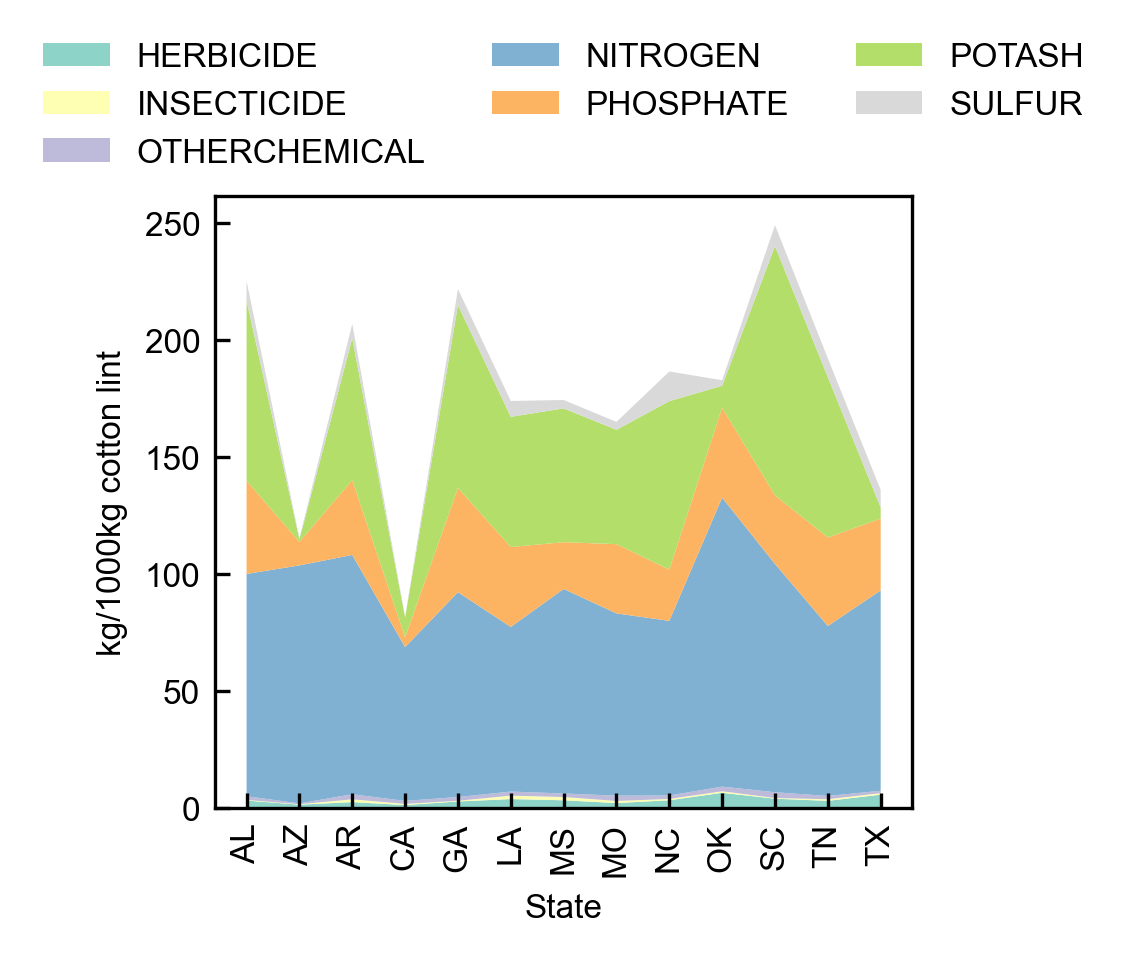

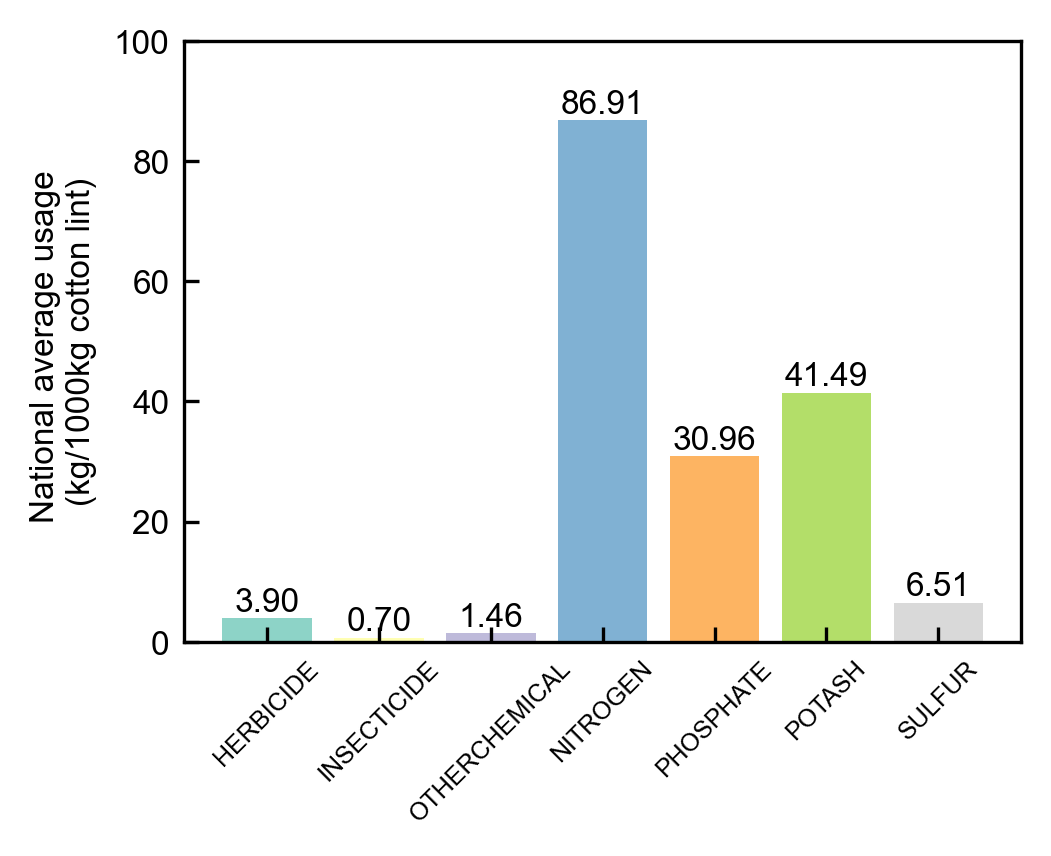

In [9]:
data_production_2019 = data_production[[2015,2019]].drop([4, 6, 10, 16]).reset_index(drop=True)
print(data_HERBICIDE)

# allocation number for cotton lint: 0.824
data_unit_HERBICIDE = data_HERBICIDE[[2015,2019]]/data_production_2019*0.824
data_unit_INSECTICIDE = data_INSECTICIDE[[2015,2019]]/data_production_2019*0.824
data_unit_OTHERCHEMICAL = data_OTHERCHEMICAL[[2015,2019]]/data_production_2019*0.824
data_unit_NITROGEN = data_NITROGEN[[2015,2019]]/data_production_2019*0.824
data_unit_PHOSPHATE = data_PHOSPHATE[[2015,2019]]/data_production_2019*0.824
data_unit_POTASH = (data_POTASH[[2015,2019]]/data_production_2019).interpolate(axis=1)*0.824
data_unit_SULFUR = (data_SULFUR[[2015,2019]]/data_production_2019).interpolate(axis=1)*0.824

# print(data_HERBICIDE[[2015,2019]])

# print(data_unit_HERBICIDE, data_unit_INSECTICIDE,data_unit_OTHERCHEMICAL,data_unit_NITROGEN,data_unit_PHOSPHATE,
#       data_unit_POTASH,data_unit_SULFUR )

cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

x = range(13)

# convert lb/bale = lb/480lb, lb/480lb*2.08 = kg/1000kg
y = np.vstack([data_unit_HERBICIDE[2019]*2.08, data_unit_INSECTICIDE[2019]*2.08,data_unit_OTHERCHEMICAL[2019]*2.08,
              data_unit_NITROGEN[2019]*2.08, data_unit_PHOSPHATE[2019]*2.08,data_unit_POTASH[2019]*2.08,data_unit_SULFUR[2019]*2.08])
print(y)

plt.figure(figsize=(3, 3))
plt.stackplot(x, y, colors=colors, labels=['HERBICIDE', 'INSECTICIDE','OTHERCHEMICAL','NITROGEN',
                            'PHOSPHATE','POTASH','SULFUR'])
# plt.ylabel('lb/Bale')
plt.ylabel('kg/1000kg cotton lint')
plt.xlabel('State')

plt.subplots_adjust(bottom=0.2)

plt.xticks(x, ['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS','MO','NC', 'OK','SC', 'TN', 'TX'], rotation=90)
plt.legend(bbox_to_anchor=(0.5, 1.3), loc='upper center', frameon=False, ncol=3)
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/chemical_states.tiff',dpi=300, bbox_inches='tight')

######################
######################
def culculate_average(data):
  return sum(data*data_production_2019[2019])/sum(data_production_2019[2019])*2.08

x = range(7)
y = [culculate_average(data_unit_HERBICIDE[2019]), culculate_average(data_unit_INSECTICIDE[2019]),
     culculate_average(data_unit_OTHERCHEMICAL[2019]),culculate_average(data_unit_NITROGEN[2019]),
     culculate_average(data_unit_PHOSPHATE[2019]),culculate_average(data_unit_POTASH[2019]),
     culculate_average(data_unit_SULFUR[2019])]
print(y)

plt.figure(figsize=(3.6, 2.6))
bars = plt.bar(x, y, color=colors, label=['HERBICIDE', 'INSECTICIDE','OTHERCHEMICAL','NITROGEN','PHOSPHATE','POTASH','SULFUR'])

# Annotate the bars with the values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=8, color='black')


plt.yticks(np.arange(0, 101, step=20))

plt.ylabel('National average usage \n(kg/1000kg cotton lint)')
plt.xticks(x, ['HERBICIDE', 'INSECTICIDE','OTHERCHEMICAL','NITROGEN','PHOSPHATE','POTASH','SULFUR'], rotation=45,fontsize=6)
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, ncol=1)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_average_FerandChem.tiff',dpi=300, bbox_inches='tight')

# print(y)



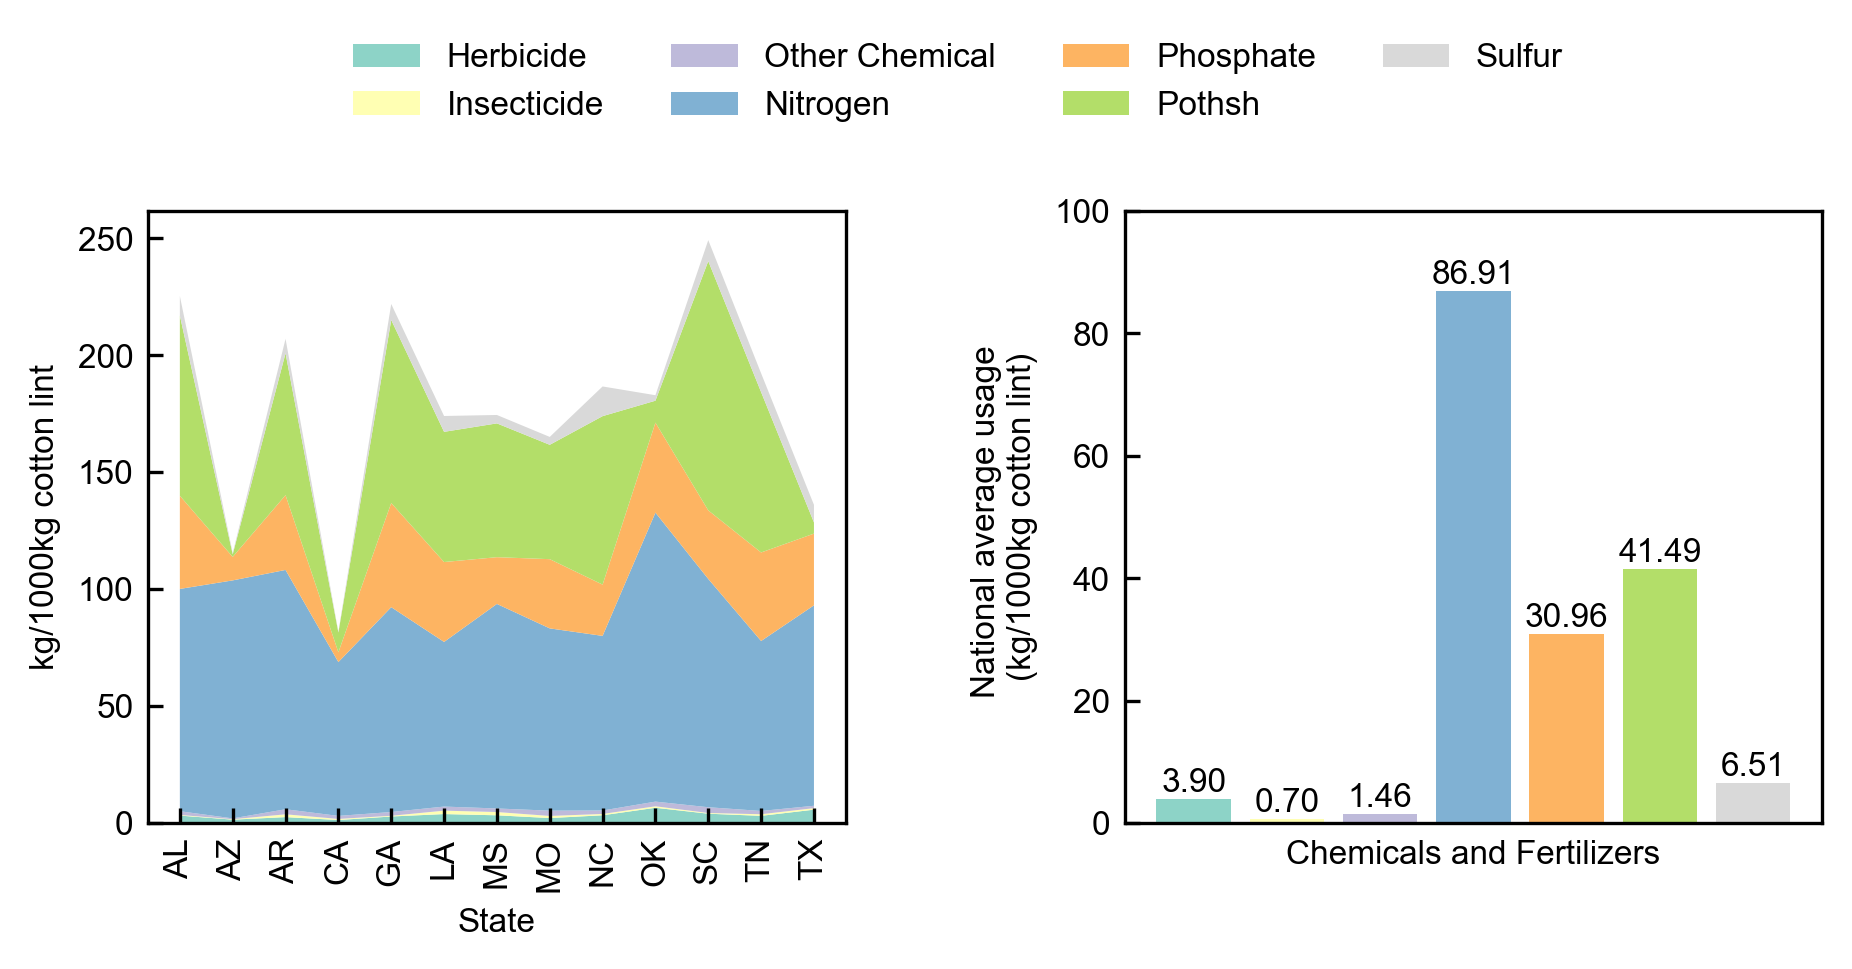

In [10]:
import numpy as np
import matplotlib.pyplot as plt

cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

x1 = range(13)
y1 = np.vstack([data_unit_HERBICIDE[2019]*2.08, data_unit_INSECTICIDE[2019]*2.08, data_unit_OTHERCHEMICAL[2019]*2.08,
                data_unit_NITROGEN[2019]*2.08, data_unit_PHOSPHATE[2019]*2.08, data_unit_POTASH[2019]*2.08, data_unit_SULFUR[2019]*2.08])

x2 = range(7)
def calculate_average(data):
    return sum(data * data_production_2019[2019]) / sum(data_production_2019[2019]) * 2.08

y2 = [calculate_average(data_unit_HERBICIDE[2019]), calculate_average(data_unit_INSECTICIDE[2019]),
      calculate_average(data_unit_OTHERCHEMICAL[2019]), calculate_average(data_unit_NITROGEN[2019]),
      calculate_average(data_unit_PHOSPHATE[2019]), calculate_average(data_unit_POTASH[2019]),
      calculate_average(data_unit_SULFUR[2019])]

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3))

# First subplot: Stacked Area Chart
axs[0].stackplot(x1, y1, colors=colors, labels=['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'])
axs[0].set_ylabel('kg/1000kg cotton lint')
axs[0].set_xlabel('State')
axs[0].set_xticks(x1)
axs[0].set_xticklabels(['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS', 'MO', 'NC', 'OK', 'SC', 'TN', 'TX'], rotation=90)
# axs[0].legend(bbox_to_anchor=(0.5, 1.3), loc='upper center', frameon=False, ncol=3)

# Second subplot: Bar Chart
bars = axs[1].bar(x2, y2, color=colors, label=['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'])
for bar in bars:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=8, color='black')

axs[1].set_yticks(np.arange(0, 101, step=20))
axs[1].set_ylabel('National average usage \n(kg/1000kg cotton lint)')
axs[1].set_xlabel('Chemicals and Fertilizers')
axs[1].set_xticks([])
# axs[1].set_xticklabels(['HERBICIDE', 'INSECTICIDE', 'OTHERCHEMICAL', 'NITROGEN', 'PHOSPHATE', 'POTASH', 'SULFUR'],
                      #  rotation=45, fontsize=6)
fig.legend(['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'],
           loc='upper center', bbox_to_anchor=(0.5, 1.1), frameon=False, ncol=4)

plt.subplots_adjust(wspace=0.4, bottom=0.2)  # Adjust spacing
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/merged_chemical_usage.tiff', dpi=300, bbox_inches='tight')

plt.show()


Nitrogen Usage by State (kg/1000kg cotton lint):
--------------------------------------------------
AL: 95.03
AZ: 101.74
AR: 102.31
CA: 65.76
GA: 87.57
LA: 70.38
MS: 87.44
MO: 77.92
NC: 74.65
OK: 123.54
SC: 97.59
TN: 72.66
TX: 85.68
--------------------------------------------------
National Average Nitrogen Usage: 86.91 kg/1000kg cotton lint



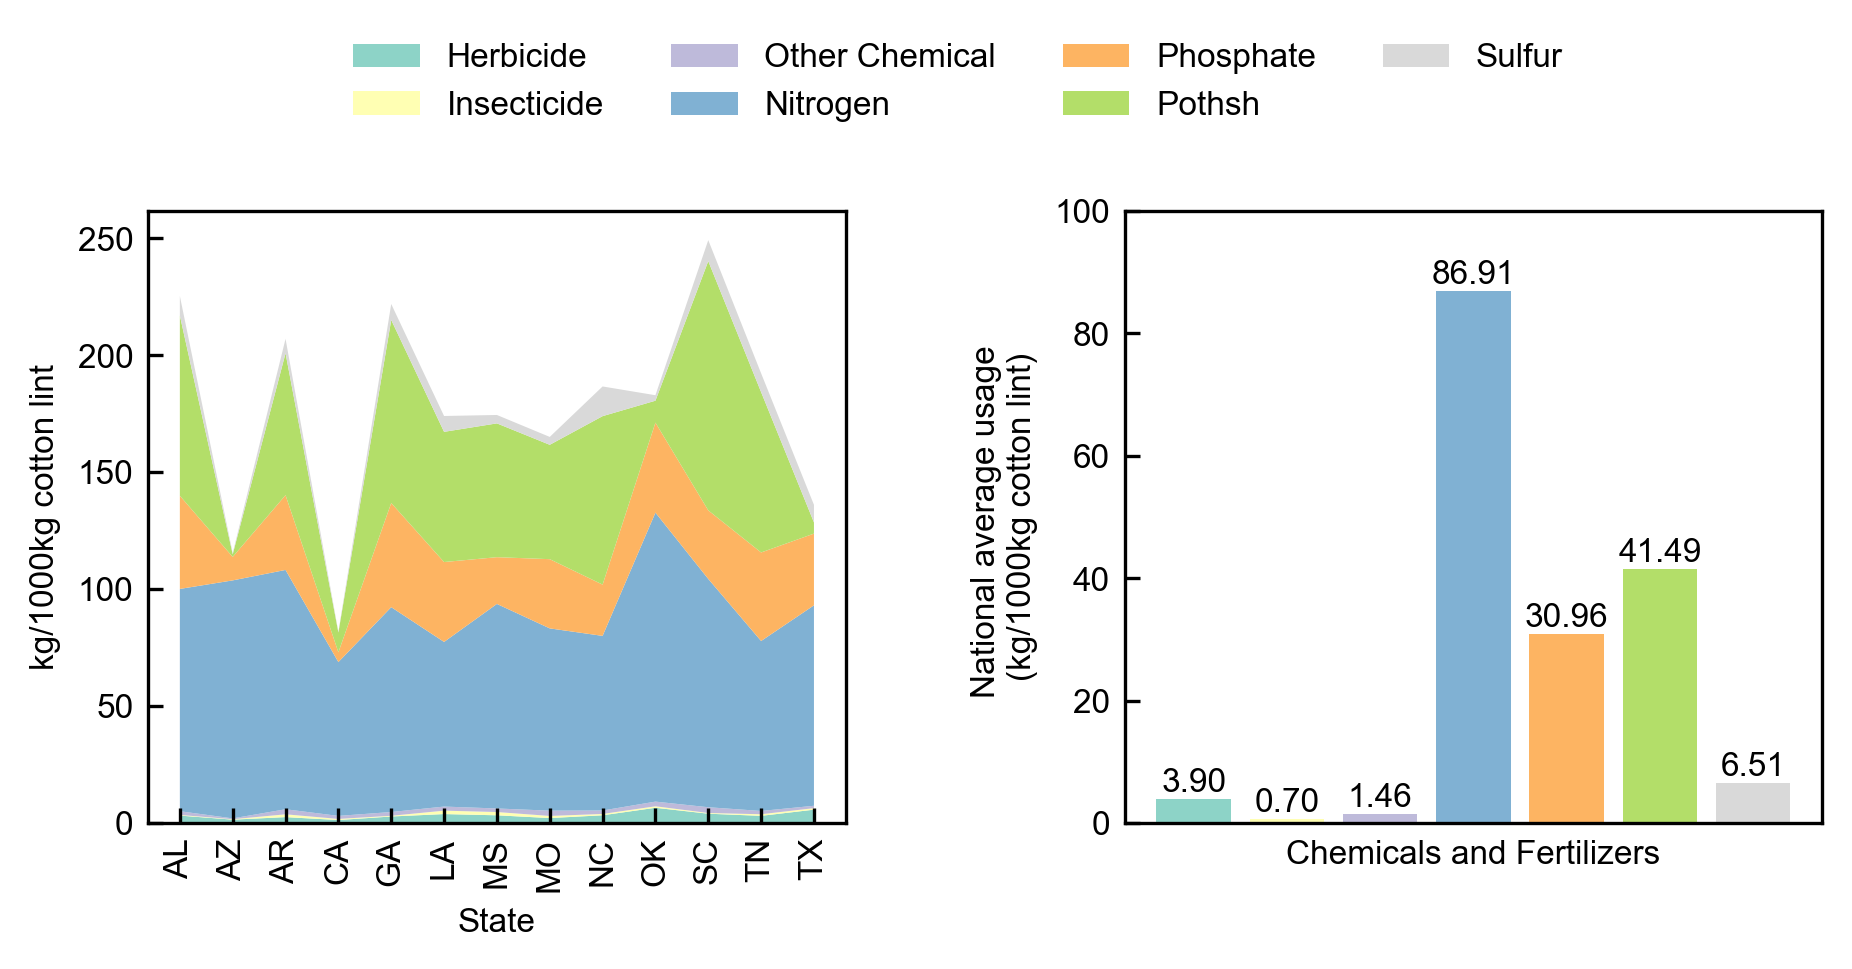

In [11]:
import numpy as np
import matplotlib.pyplot as plt

cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

x1 = range(13)
y1 = np.vstack([data_unit_HERBICIDE[2019]*2.08, data_unit_INSECTICIDE[2019]*2.08, data_unit_OTHERCHEMICAL[2019]*2.08,
                data_unit_NITROGEN[2019]*2.08, data_unit_PHOSPHATE[2019]*2.08, data_unit_POTASH[2019]*2.08, data_unit_SULFUR[2019]*2.08])

# Print nitrogen usage for each state
states = ['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS', 'MO', 'NC', 'OK', 'SC', 'TN', 'TX']
nitrogen_usage = data_unit_NITROGEN[2019]*2.08

print("Nitrogen Usage by State (kg/1000kg cotton lint):")
print("-" * 50)
for i, state in enumerate(states):
    print(f"{state}: {nitrogen_usage[i]:.2f}")
print("-" * 50)

x2 = range(7)
def calculate_average(data):
    return sum(data * data_production_2019[2019]) / sum(data_production_2019[2019]) * 2.08

y2 = [calculate_average(data_unit_HERBICIDE[2019]), calculate_average(data_unit_INSECTICIDE[2019]),
      calculate_average(data_unit_OTHERCHEMICAL[2019]), calculate_average(data_unit_NITROGEN[2019]),
      calculate_average(data_unit_PHOSPHATE[2019]), calculate_average(data_unit_POTASH[2019]),
      calculate_average(data_unit_SULFUR[2019])]

# Print national average nitrogen usage
print(f"National Average Nitrogen Usage: {y2[3]:.2f} kg/1000kg cotton lint")
print()

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3))

# First subplot: Stacked Area Chart
axs[0].stackplot(x1, y1, colors=colors, labels=['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'])
axs[0].set_ylabel('kg/1000kg cotton lint')
axs[0].set_xlabel('State')
axs[0].set_xticks(x1)
axs[0].set_xticklabels(['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS', 'MO', 'NC', 'OK', 'SC', 'TN', 'TX'], rotation=90)
# axs[0].legend(bbox_to_anchor=(0.5, 1.3), loc='upper center', frameon=False, ncol=3)

# Second subplot: Bar Chart
bars = axs[1].bar(x2, y2, color=colors, label=['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'])
for bar in bars:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=8, color='black')

axs[1].set_yticks(np.arange(0, 101, step=20))
axs[1].set_ylabel('National average usage \n(kg/1000kg cotton lint)')
axs[1].set_xlabel('Chemicals and Fertilizers')
axs[1].set_xticks([])
# axs[1].set_xticklabels(['HERBICIDE', 'INSECTICIDE', 'OTHERCHEMICAL', 'NITROGEN', 'PHOSPHATE', 'POTASH', 'SULFUR'],
                      #  rotation=45, fontsize=6)
fig.legend(['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'],
           loc='upper center', bbox_to_anchor=(0.5, 1.1), frameon=False, ncol=4)

plt.subplots_adjust(wspace=0.4, bottom=0.2)  # Adjust spacing
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/merged_chemical_usage.tiff', dpi=300, bbox_inches='tight')

plt.show()